In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

### Step 1: Loading & Performing the EDA

This Step involves in
* Loading the dataset,
* Performing the EDA,
* Getting the insights from the data.

In [2]:
# Load the dataset
df = pd.read_csv('/content/Month_Value_1.csv')

# Parse the 'Period' column into datetime format and set it as index
df['Period'] = pd.to_datetime(df['Period'], format='%d.%m.%Y')
df.set_index('Period', inplace=True)

# Sort the index to ensure chronological order
df.sort_index(inplace=True)

print("--- Dataset Head ---")
print(df.head())
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- Summary Statistics ---")
print(df.describe())

--- Dataset Head ---
                 Revenue  Sales_quantity  Average_cost  \
Period                                                   
2015-01-01  1.601007e+07         12729.0   1257.763541   
2015-02-01  1.580759e+07         11636.0   1358.507000   
2015-03-01  2.204715e+07         15922.0   1384.697024   
2015-04-01  1.881458e+07         15227.0   1235.606705   
2015-05-01  1.402148e+07          8620.0   1626.621765   

            The_average_annual_payroll_of_the_region  
Period                                                
2015-01-01                                30024676.0  
2015-02-01                                30024676.0  
2015-03-01                                30024676.0  
2015-04-01                                30024676.0  
2015-05-01                                30024676.0  

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 96 entries, 2015-01-01 to 2022-12-01
Data columns (total 4 columns):
 #   Column                                

In [11]:
df.duplicated().sum()

np.int64(0)

In [3]:
df.sort_index(inplace=True)
df

,Revenue,Sales_quantity,Average_cost,The_average_annual_payroll_of_the_region
Period,,,,
2015-01-01,1.601007e+07,12729.0,1257.763541,30024676.0
2015-02-01,1.580759e+07,11636.0,1358.507000,30024676.0
2015-03-01,2.204715e+07,15922.0,1384.697024,30024676.0
2015-04-01,1.881458e+07,15227.0,1235.606705,30024676.0
2015-05-01,1.402148e+07,8620.0,1626.621765,30024676.0
...,...,...,...,...
2022-08-01,NaN,NaN,NaN,NaN
2022-09-01,NaN,NaN,NaN,NaN
2022-10-01,NaN,NaN,NaN,NaN


In [4]:
df.shape

(96, 4)


### Step 2: Seasonal Decomposition & Trend Analysis

To understand if the data has structural patterns, we decompose the time series into three components: Trend, Seasonality, and Residuals (noise).

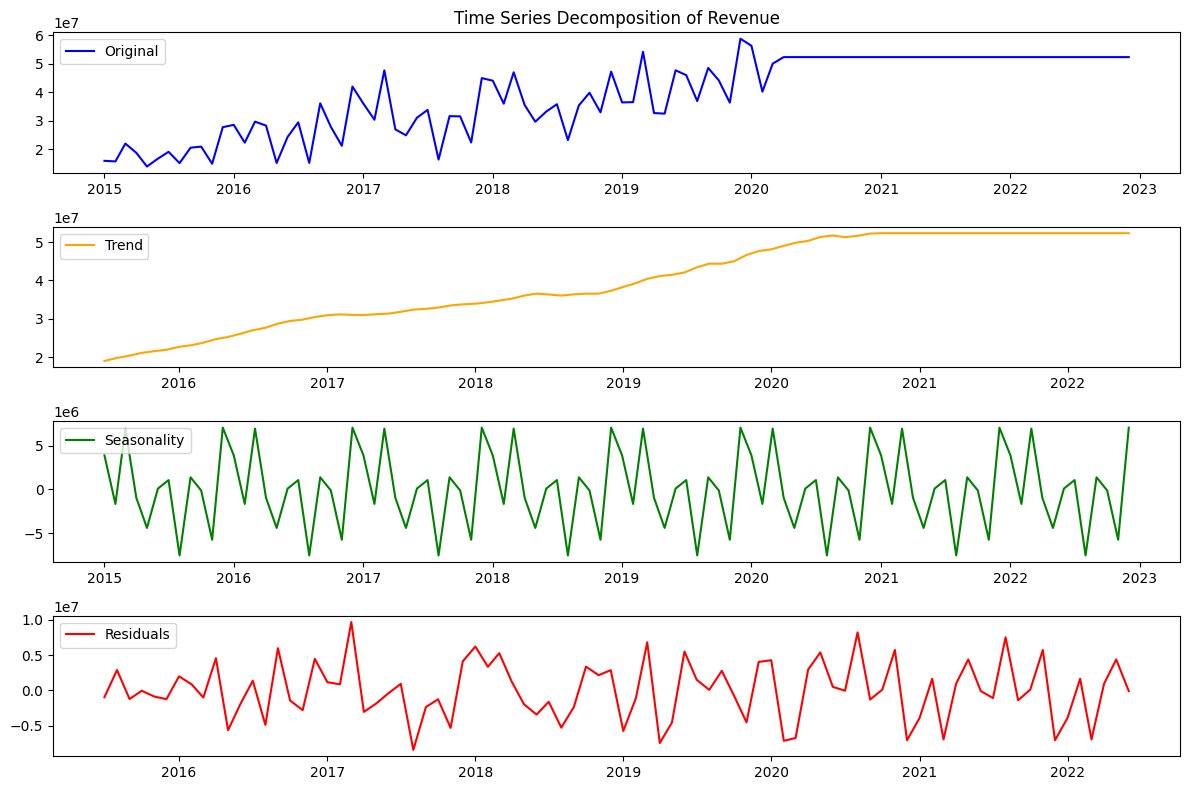

In [5]:
# Fill missing values in 'Revenue' before decomposition
df['Revenue'] = df['Revenue'].interpolate()

# Decompose the Revenue series (assuming monthly frequency, period=12)
decomposition = seasonal_decompose(df['Revenue'], model='additive', period=12)

# Plotting the components
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(df['Revenue'], label='Original', color='blue')
plt.legend(loc='upper left')
plt.title('Time Series Decomposition of Revenue')

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality', color='green')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Result-

As we can see that theres Seasonality in the Dataset. We're good to move further.

### Step 3: Feature Engineering for Time Series

Machine learning algorithms like Random Forest cannot natively interpret raw dates.
We must convert the time index into numerical features that capture patterns, plus Lag Features to capture historical dependency.

In [6]:
# Extracting Time Features
df['Year'] = df.index.year
df['Month'] = df.index.month

# Creating Lag Features (Using past 1 and 2 months of revenue to predict current month)
df['Lag_1'] = df['Revenue'].shift(1)
df['Lag_2'] = df['Revenue'].shift(2)

# Creating Rolling Statistics
df['Rolling_Mean_3'] = df['Revenue'].shift(1).rolling(window=3).mean()

# Drop missing values created due to lagging
df.dropna(inplace=True)

# Define Features and Target
X = df[['Year', 'Month', 'Sales_quantity', 'Average_cost', 'The_average_annual_payroll_of_the_region', 'Lag_1', 'Lag_2', 'Rolling_Mean_3']]
y = df['Revenue']

print("Features engineered successfully. Feature matrix shape:", X.shape)

Features engineered successfully. Feature matrix shape: (61, 8)


### Step 4: Time-Based Train-Test Split

Standard random train-test splits cannot be used in time series because they violate the temporal order (causing data leakage from the future into the past).
We split the data chronologically.

In [7]:

# Using the last 12 months as the test set to evaluate forecasting performance
test_size = 12

X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

print(f"Train set size: {X_train.shape[0]} months")
print(f"Test set size: {X_test.shape[0]} months")


Train set size: 49 months
Test set size: 12 months


### Step 5: Model Building and Evaluation

We train three tree-based algorithms: Decision Tree, Random Forest, and Gradient Boosting. We evaluate them using Mean Absolute Error (MAE) and R-squared (R2) Score.

In [8]:
# Initialize models
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results[name] = {"MAE": mae, "R2 Score": r2, "Predictions": predictions}

# Display Performance Table
results_df = pd.DataFrame(results).T[['MAE', 'R2 Score']]
print(results_df)

                              MAE  R2 Score
Decision Tree      4336942.903778  0.512721
Random Forest      5068861.070817  0.370786
Gradient Boosting  3586185.345151  0.662404


### Step 6: Visualizing Predictions vs Actuals

This visualization is used to display how well the best performing model (Gradient Boosting) tracks the true data points.

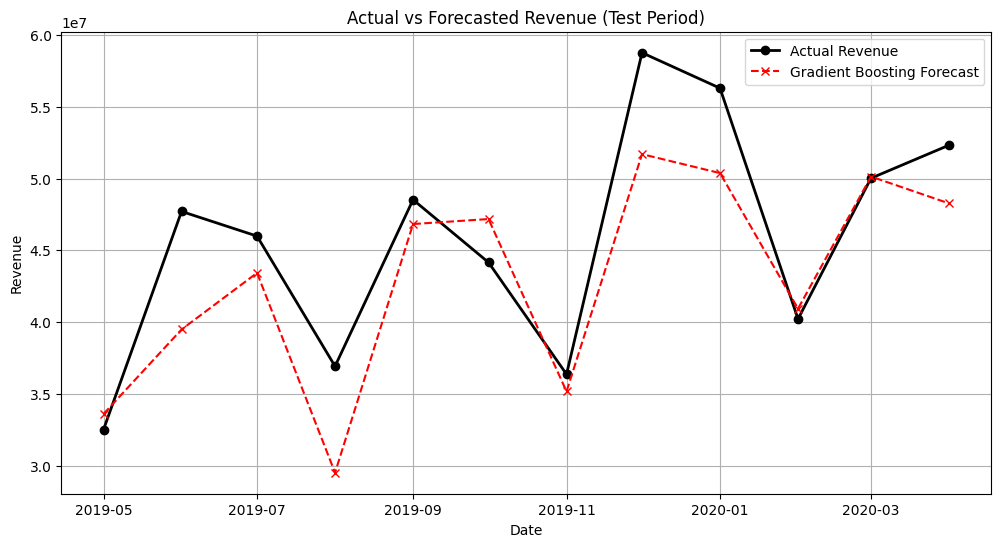

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual Revenue', marker='o', color='black', linewidth=2)
plt.plot(y_test.index, results['Gradient Boosting']['Predictions'], label='Gradient Boosting Forecast', marker='x', linestyle='--', color='red')

plt.title('Actual vs Forecasted Revenue (Test Period)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, predictions)
print(f"MAPE: {mape:.2%}")

MAPE: 7.67%


###Best Model: Gradient Boosting Regressor

* **MAE**: 3,586,185
* **R² Score**: 0.662
* **MAPE**: 7.62%